In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers
import speed_plotting_helpers

In [3]:
activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125


In [4]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import tqdm

# Logistic function
def logistic(t, A, k, t0):
    return A / (1 + np.exp(-k * (t - t0)))

df = activities  # your original dataframe

results = []

for adseq, group in tqdm.tqdm(df.groupby('ADseq')):
    t = group['time'].values
    y = group['activity_norm'].values
    y_err = group['error'].values
    
    # initial guesses
    A_guess = y.max()
    k_guess = 0.1
    t0_guess = t[np.argmin(np.abs(y - A_guess/2))]
    
    try:
        # weighted logistic fit
        popt, pcov = curve_fit(
            logistic, t, y,
            p0=[A_guess, k_guess, t0_guess],
            sigma=y_err,
            absolute_sigma=True,
            maxfev=5000
        )
        
        # fitted parameters
        A_fit, k_fit, t0_fit = popt
        
        # smooth curve only over observed time points
        t_fine = np.linspace(t.min(), t.max(), 1000)
        y_fit = logistic(t_fine, A_fit, k_fit, t0_fit)
        
        # maximum value **within the observed interval**
        max_curve = y_fit.max()
        half_max_curve = max_curve / 2
        
        # time where fitted curve crosses half-max
        t_half_from_curve = t_fine[np.argmin(np.abs(y_fit - half_max_curve))]
        
        # predicted y at measured points
        y_pred = logistic(t, *popt)
        r2 = r2_score(y, y_pred)
        
        # parameter uncertainties
        perr = np.sqrt(np.diag(pcov))
        
        results.append({
            'ADseq': adseq,
            'R2': r2,
            'observed_strength': max_curve,      # max curve value in observed interval
            't_half': t_half_from_curve,         # half-max time
            'speed': k_fit,
            'A_err': perr[0],
            'k_err': perr[1],
            't0_err': perr[2]
        })
        
    except RuntimeError:
        results.append({
            'ADseq': adseq,
            'R2': np.nan,
            'observed_strength': np.nan,
            't_half': np.nan,
            'speed': np.nan,
            'A_err': np.nan,
            'k_err': np.nan,
            't0_err': np.nan
        })

results_df = pd.DataFrame(results)
print(results_df.head())

100%|██████████| 1709/1709 [00:02<00:00, 735.07it/s]


                                      ADseq        R2  observed_strength  \
0  AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS  0.977080           1.143164   
1  AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS  0.937996           1.921117   
2  AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN  0.962433           1.870561   
3  AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI  0.967676           2.323555   
4  AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT  0.969360           0.883255   

      t_half     speed     A_err     k_err     t0_err  
0   8.498498  0.501244  0.228650  0.328210   2.109791  
1   4.834835  0.720401  0.024548  0.128958   0.269447  
2   4.384384  0.455876  0.046699  0.092673   0.345533  
3   4.444444  0.618352  0.090207  0.222306   0.325691  
4  15.165165  0.153576  1.384366  0.376069  29.524860  


In [5]:
results_df

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0.977080,1.143164,8.498498,0.501244,0.228650,0.328210,2.109791
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,0.937996,1.921117,4.834835,0.720401,0.024548,0.128958,0.269447
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,0.962433,1.870561,4.384384,0.455876,0.046699,0.092673,0.345533
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,0.967676,2.323555,4.444444,0.618352,0.090207,0.222306,0.325691
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,0.969360,0.883255,15.165165,0.153576,1.384366,0.376069,29.524860
...,...,...,...,...,...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,0.968062,1.426421,9.849850,0.264514,0.103532,0.067159,0.941904
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,0.943678,1.069386,14.534535,0.246827,0.165062,0.075854,1.657016
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,0.961248,3.861668,3.963964,0.959056,0.102850,0.506866,0.587712
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,0.952840,2.465108,5.165165,0.448922,0.064132,0.052426,0.391409


In [6]:
ok = results_df[results_df["R2"] >= 0.7]
print(f"Keeping {len(ok)} / {len(results_df)} sequences ({100*len(ok)/len(results_df):.1f}%)")

Keeping 1690 / 1709 sequences (98.9%)


In [7]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/logistic_fit_baseline_norm.csv")

In [8]:
not_ok = results_df[results_df["R2"] < 0.7]
not_ok

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
101,ASRSSSSPSYIDFTSVTTASTQSSWLSSPAPHAYRHQLNT,0.500414,1.229955,9.429429,0.275715,2.870671e-01,0.129913,2.955165e+00
113,AVINHFRGRRLWTMEEVWEKGVLDTATHIPAVFLGVLLNV,0.641591,0.779818,21.801802,0.084538,9.325939e+09,0.237157,3.143458e+06
251,DSTIAPYSRHHSVFGKFAAHEAARESFWGTTGAGAPLTPL,0.550923,0.923117,14.264264,0.044086,4.985906e+09,0.126146,3.578922e+06
327,ERGVVAPNQNQLQGARTRIAKSTPHWNRQTDYAHAHLRNH,0.493552,0.822566,6.636637,0.109078,5.224106e-01,0.213598,1.578284e+01
459,FTNRLSSPAQNPQFYASSAPSSTVALNQQNRLARPPVPLF,0.378837,1.035614,4.234234,0.937396,4.084618e-02,0.556594,5.789501e-01
463,FVSGTVSPKDLHVDTAPPSTTFTDLSTPSFESSGYFSHDT,0.087513,2.518855,3.303303,0.249544,5.363292e-02,0.041819,5.778747e-01
720,LFQSDDSAVNGAVNWPSLFPDSAQLDSNMEAEIEAIIGGG,0.690153,4.263324,1.351351,0.162302,7.583711e-02,0.017132,4.176539e-01
981,NSTAFTNLTSPDSQYHPSPEFADYDVSPFIGDNQDLDQAL,0.383252,2.636745,4.054054,0.232017,1.308899e-01,0.047434,5.528461e-01
1126,QLDSNMEAEIEAIIGGGSEDHSNLDSSVSPSASPHARSMG,0.629356,0.818144,8.498498,0.291596,1.540138e-01,0.188710,3.706978e+00
1202,SAPNSTALTALTSPSIYNESPDFNDGYDVSPSFDSGDFGS,0.230170,0.760480,0.000000,0.015492,3.277296e+08,0.270033,6.095063e+06


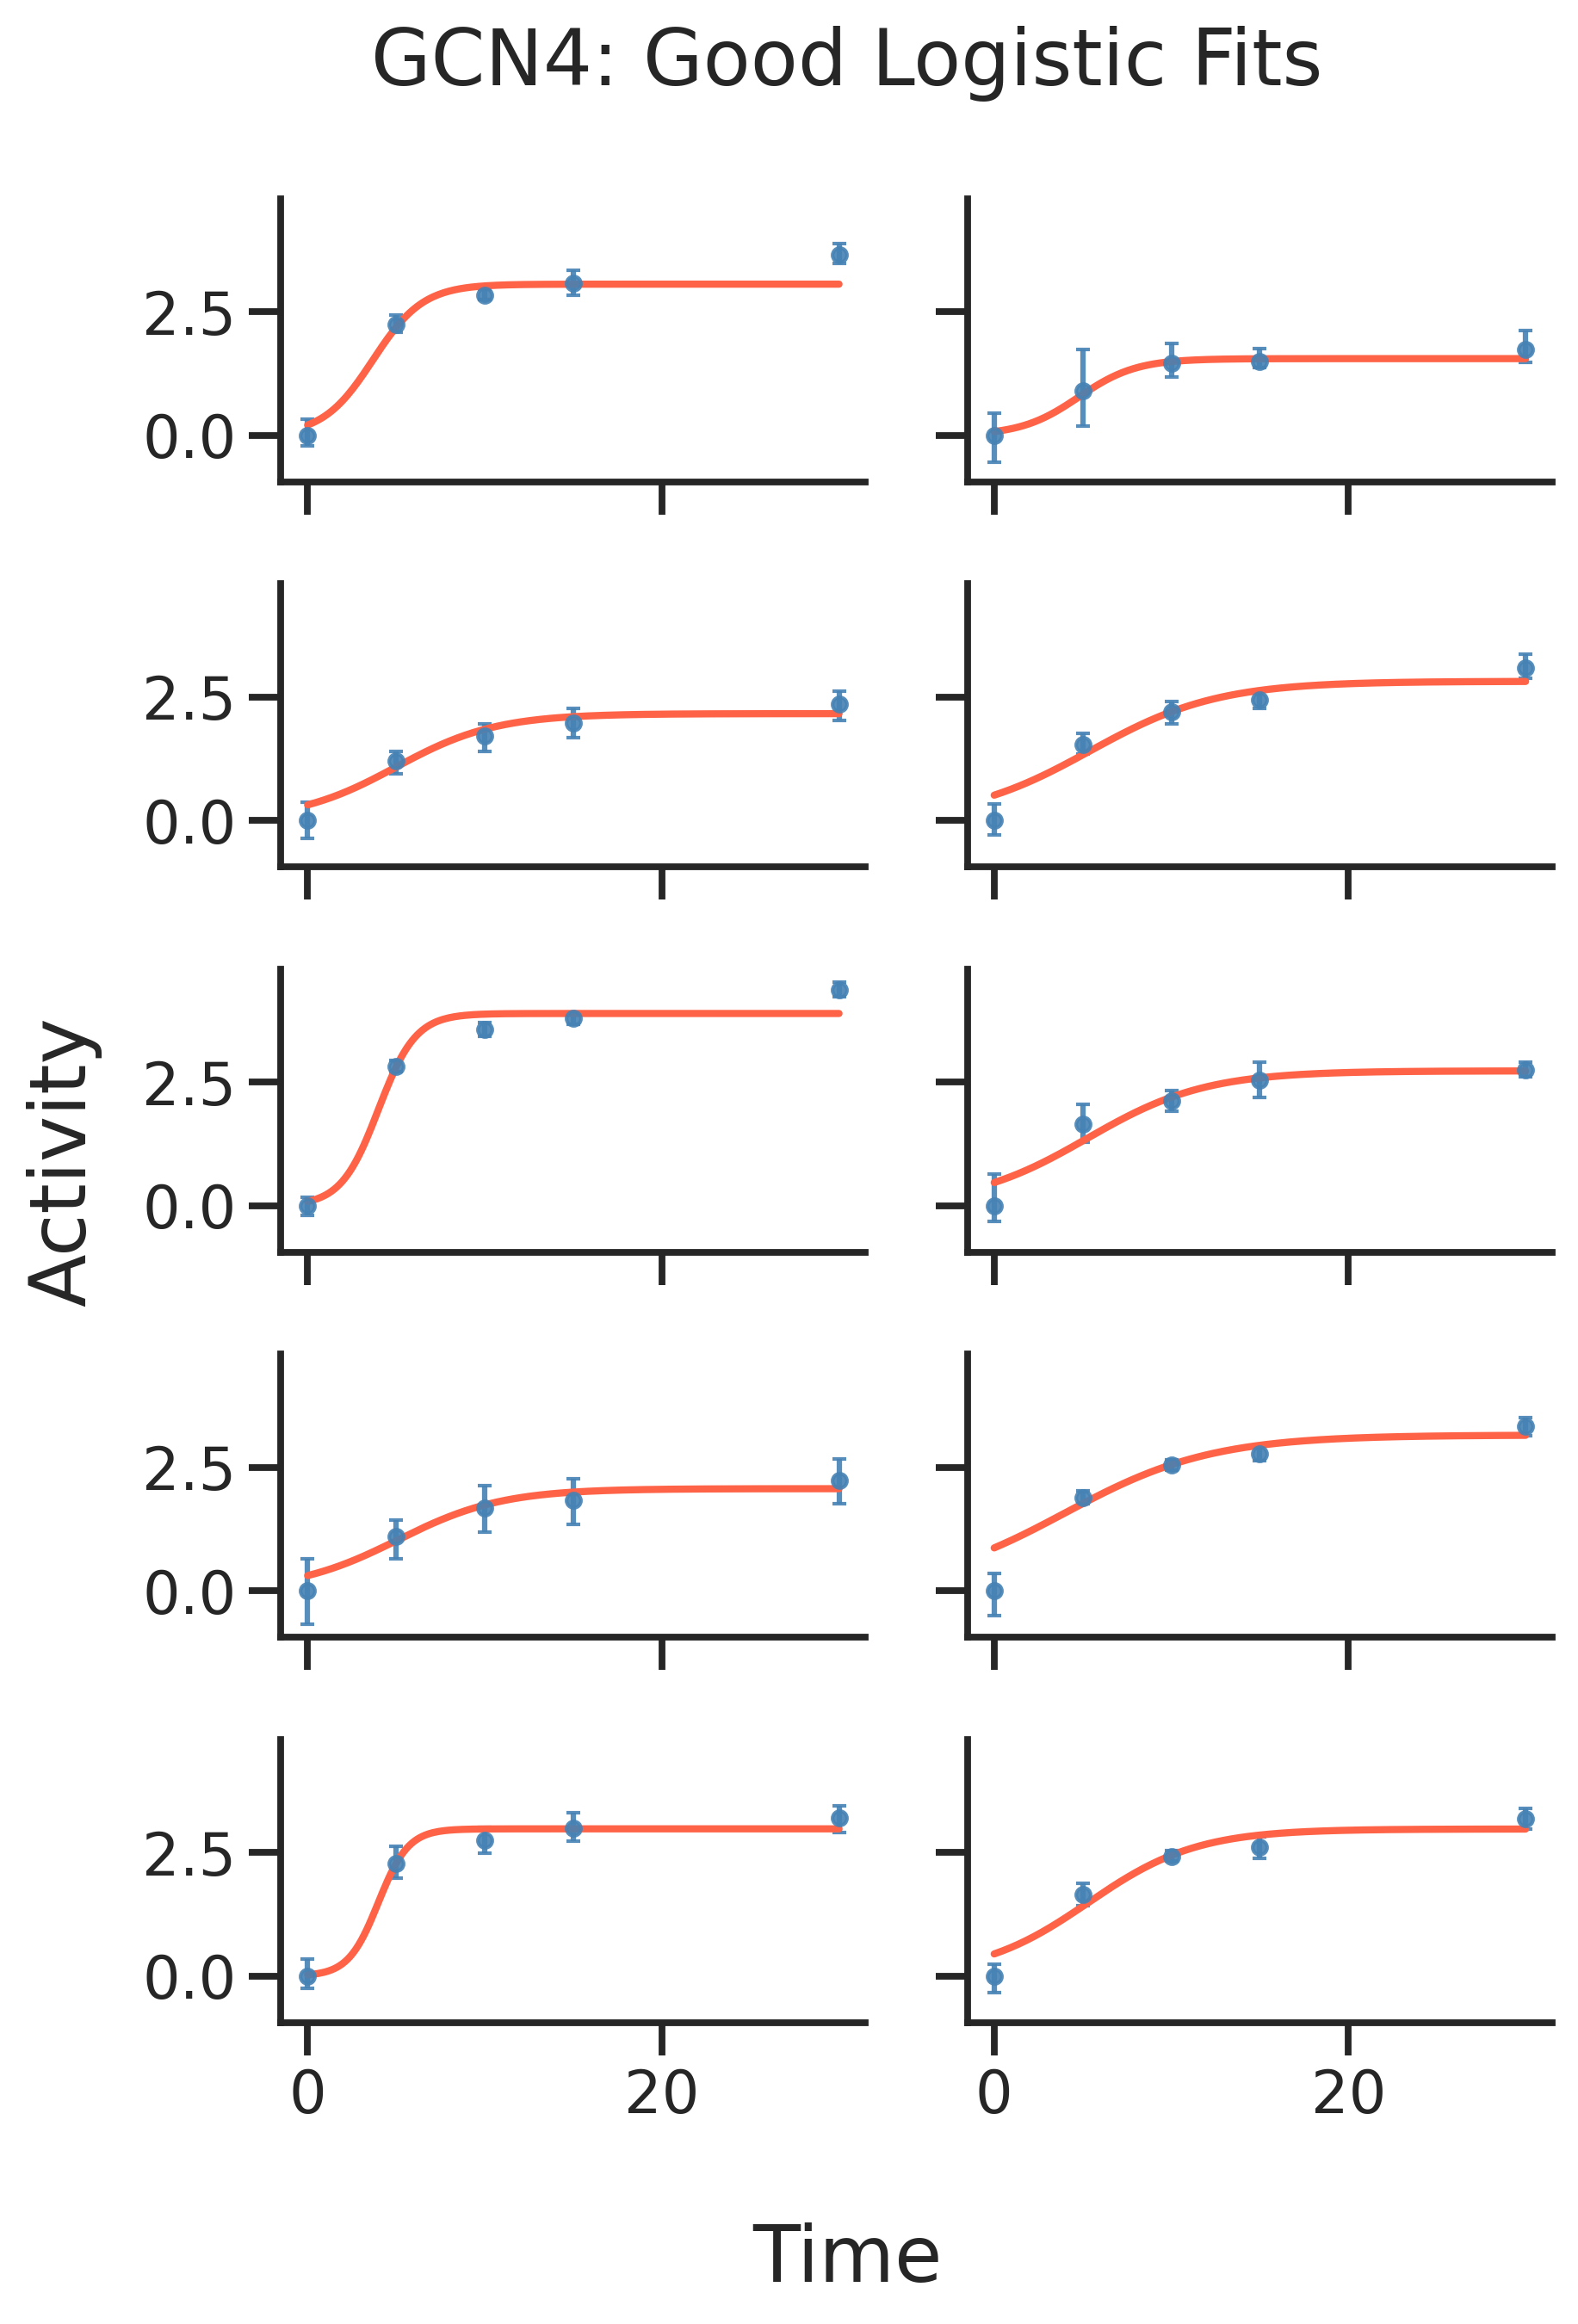

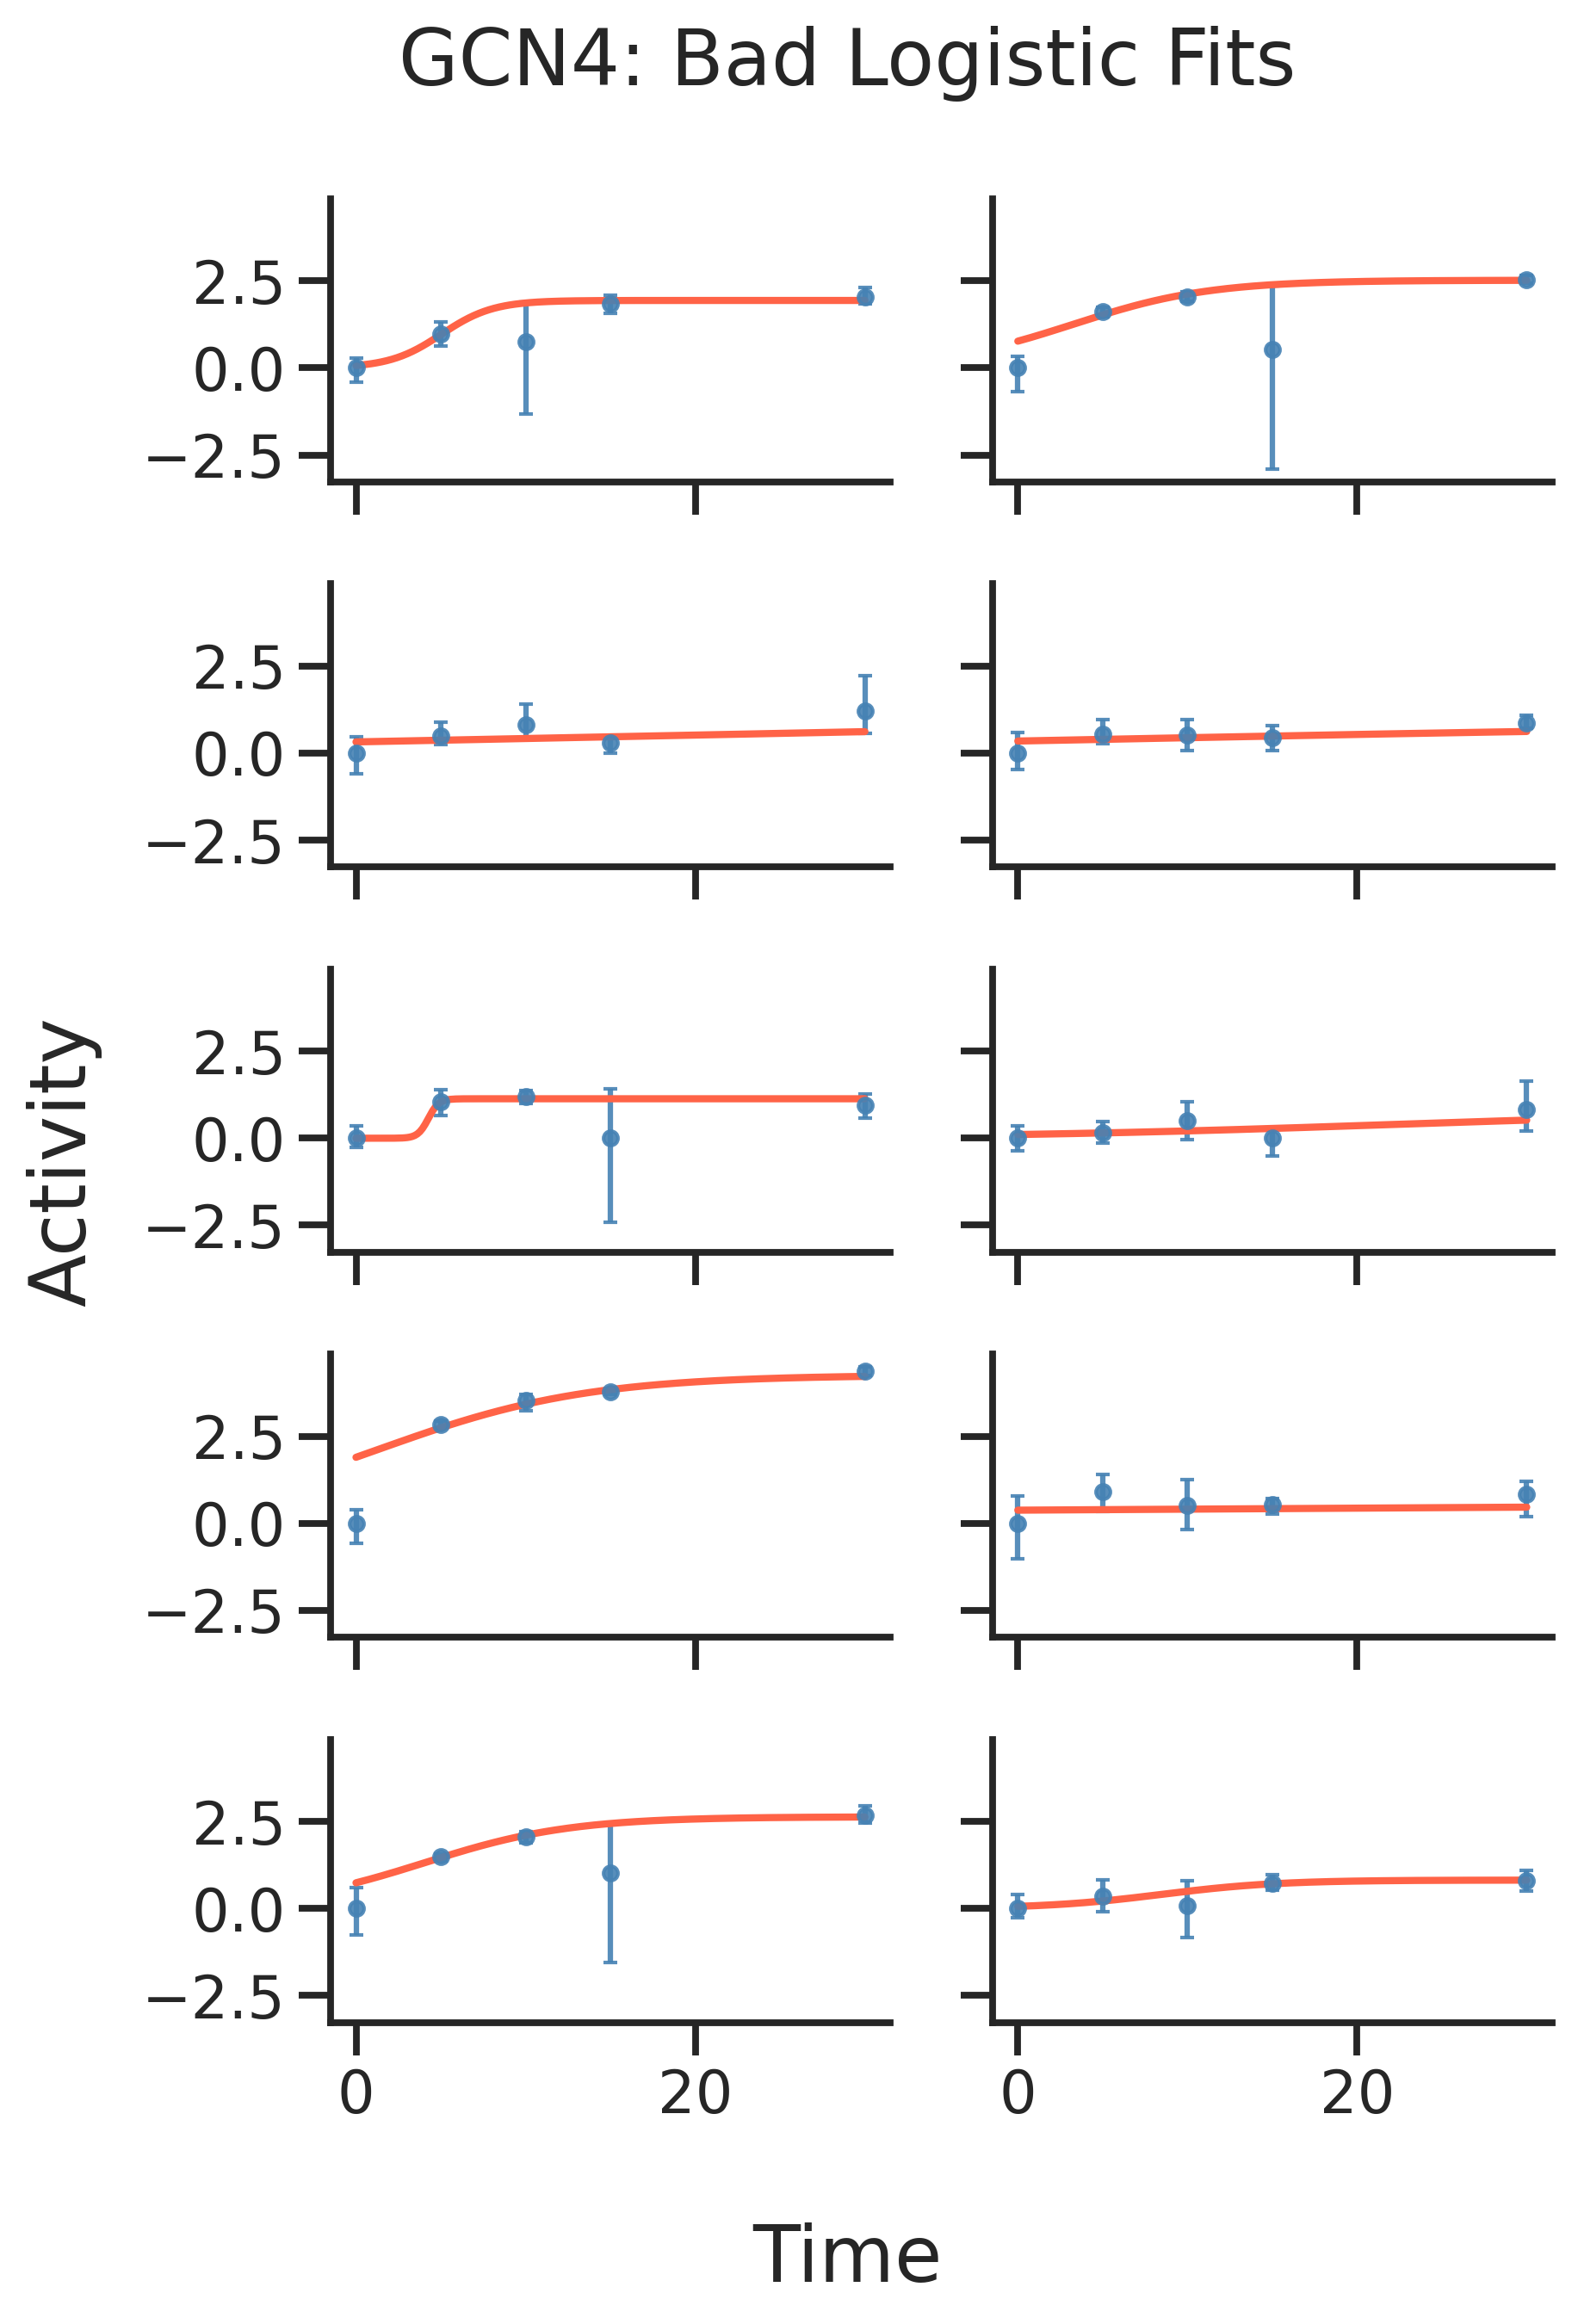

In [9]:
for df, title in zip([ok, not_ok], ["Good", "Bad"]):
    sample_adseqs = df.sample(16, random_state=44)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities,
        fit_results=results_df,
        sample_adseqs=sample_adseqs,
        model_fn=logistic,
        model_params=['observed_strength', 'speed', 't_half'],
        y_col='activity_norm',
        ci_low_col="ci_low_norm",
        ci_hi_col="ci_hi_norm",
        title=f'GCN4: {title} Logistic Fits',
    )

Pearson r = -0.587, p = 4.67e-157
Spearman rho = -0.656, p = 1.54e-208


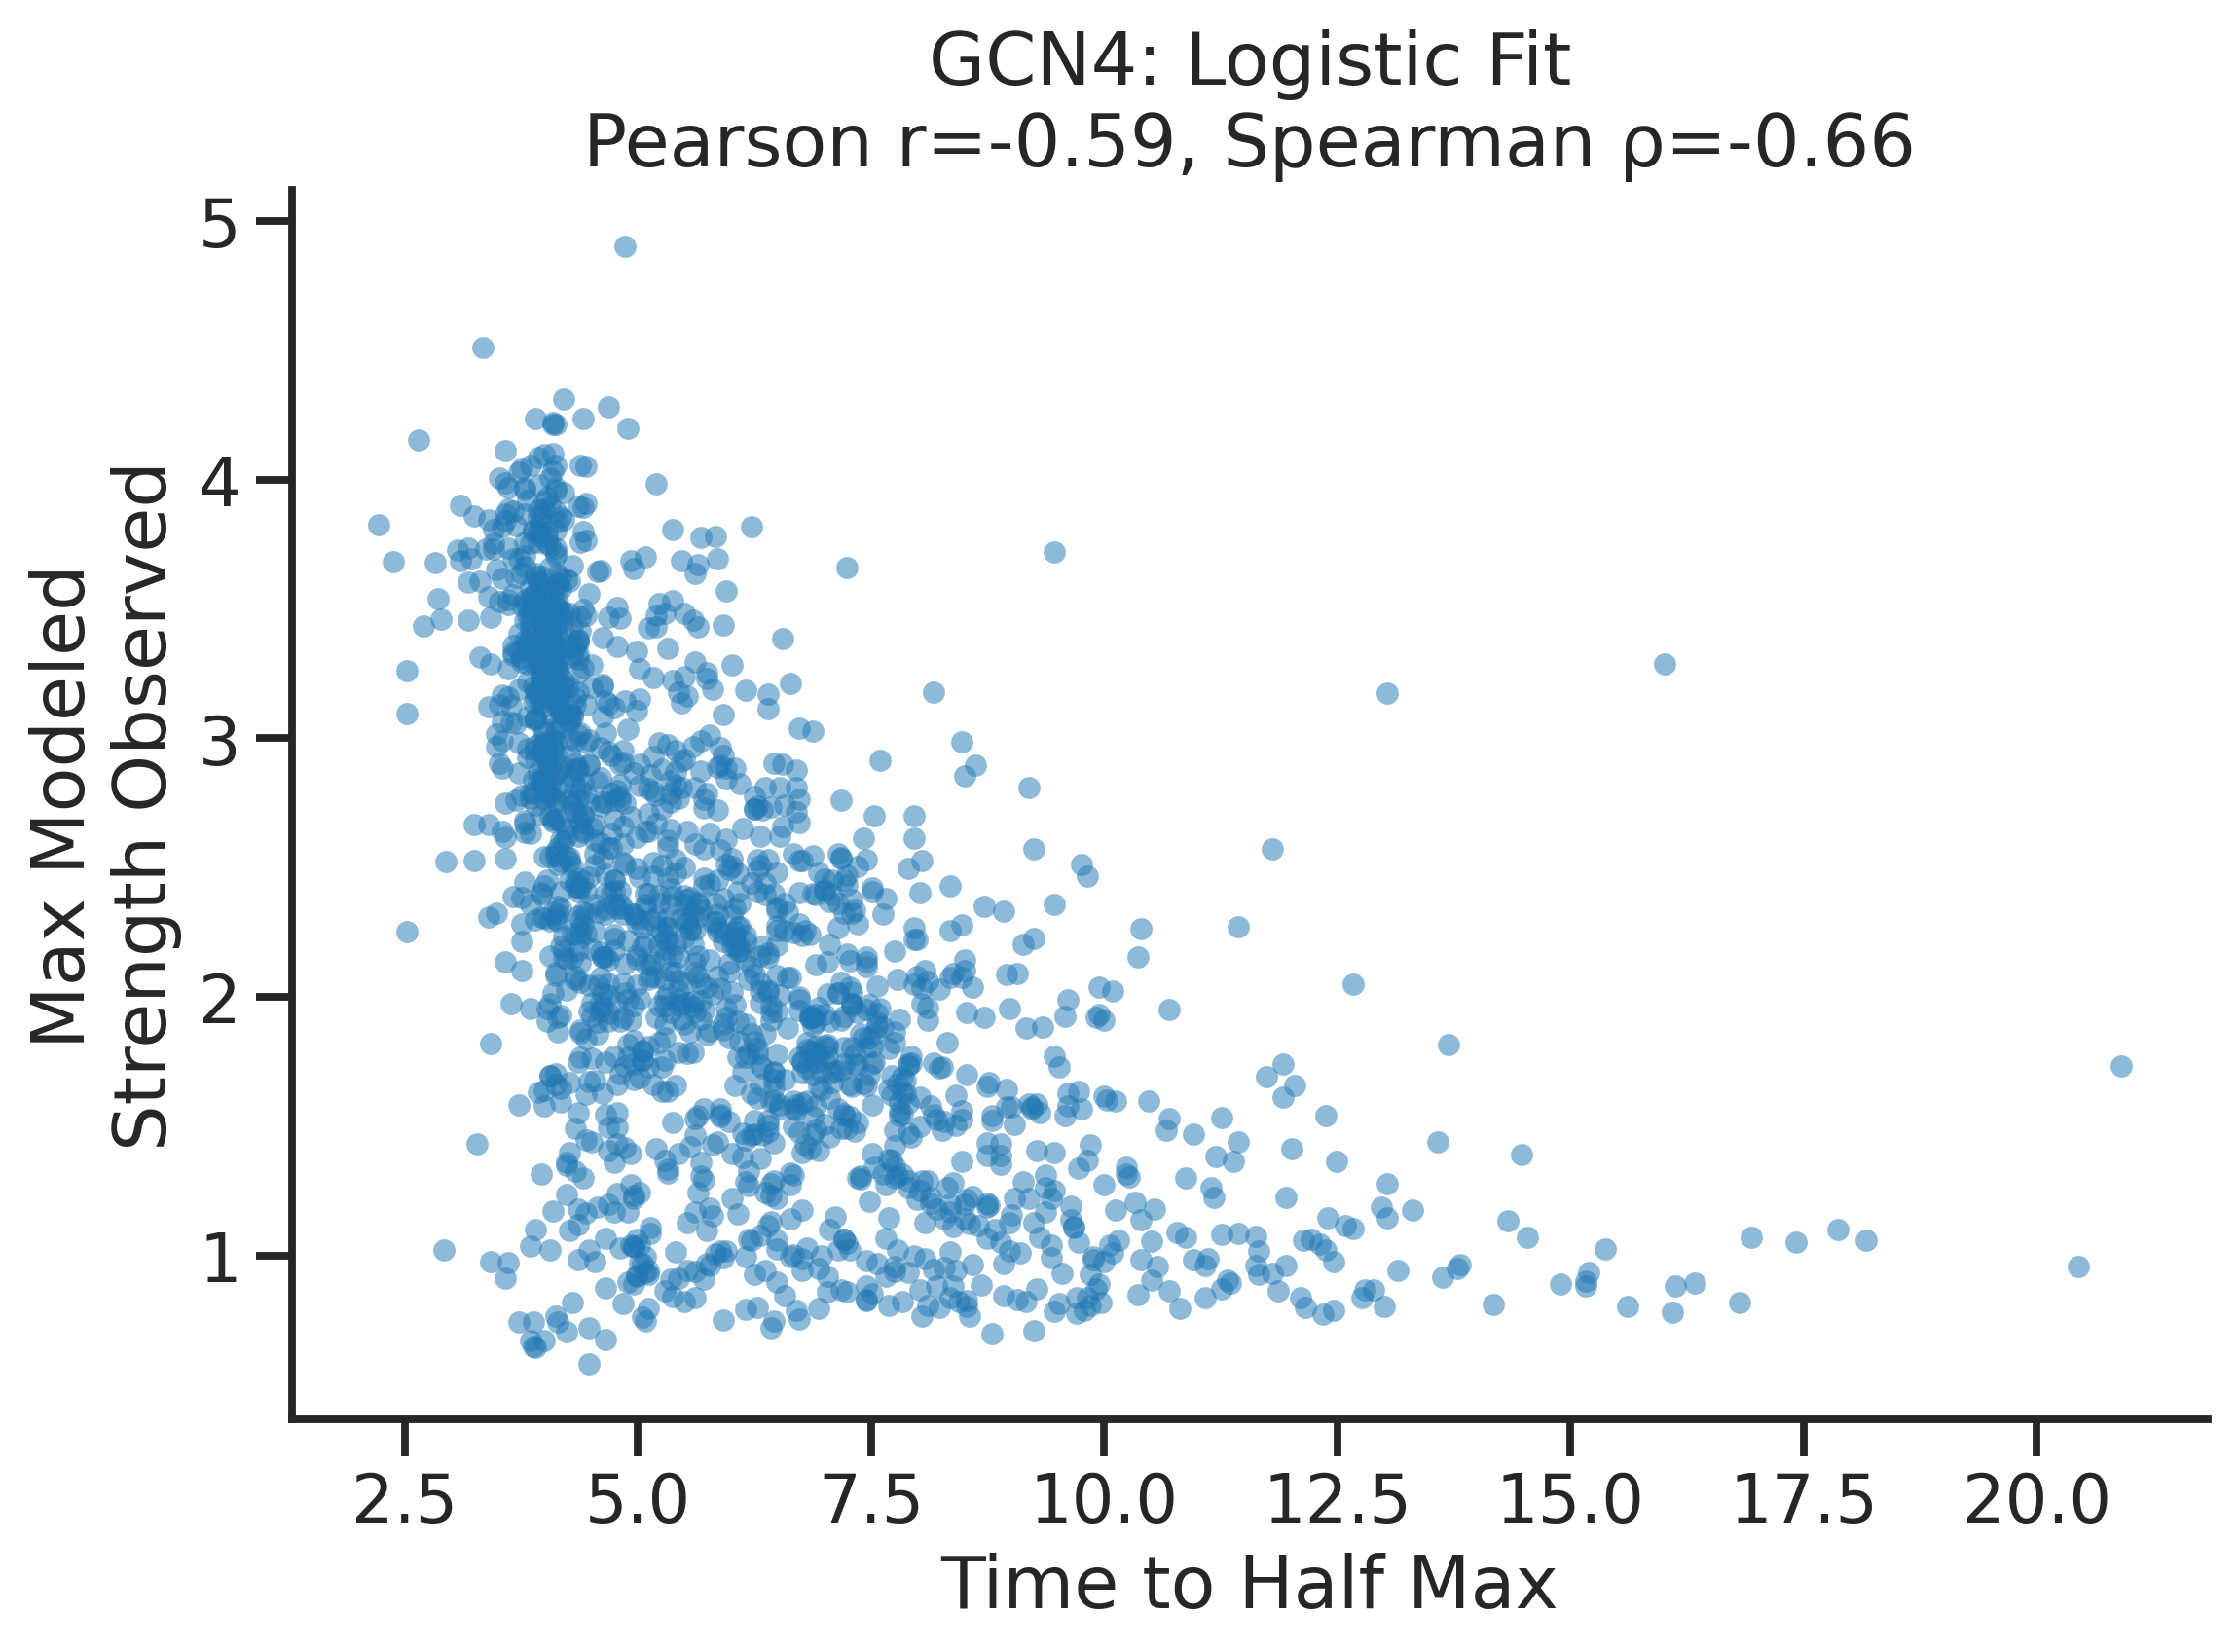

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half'], ok ['observed_strength'])
spearman_corr, spearman_p = spearmanr(ok['t_half'], ok ['observed_strength'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half'], ok['observed_strength'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Logistic Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

In [11]:
# --- filter valid sequences ---
filtered = results_df[
    (ok['speed'] >= 0) &
    (results_df['observed_strength'] >= 0) 
].copy()

# --- 1. Similar strength (A), different speed (k) ---
A_target = filtered['observed_strength'].median()
A_tol = filtered['observed_strength'].std() * 0.3

similar_A = filtered[(filtered['observed_strength'] >= A_target - A_tol) &
                     (filtered['observed_strength'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('speed')

if len(similar_A_sorted) >= 2:
    seq_simA_diffk = similar_A_sorted.iloc[[0,-1]]  # pick lowest and highest speed
else:
    seq_simA_diffk = similar_A_sorted.copy()  # fallback if not enough sequences

# --- 2. Similar speed (k), different strength (A) ---
k_target = filtered['speed'].median()
k_tol = filtered['speed'].std() * 0.3

similar_k = filtered[(filtered['speed'] >= k_target - k_tol) &
                     (filtered['speed'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('observed_strength')

if len(similar_k_sorted) >= 2:
    seq_simk_diffA = similar_k_sorted.iloc[[0, -1]]  # pick lowest and highest strength
else:
    seq_simk_diffA = similar_k_sorted.copy()  # fallback

# --- combine sequences to plot ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA]).reset_index(drop=True)
to_plot

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
0,NFSIASRSSSSFSNPFTTFDSTSFTTDNHQQSWLPSPSPT,0.873732,1.932342,9.939940,0.114160,0.397285,4.377730e-02,3.263594
1,NDFDTTVLSPQQFSTAGLGPVPDSIAGAPSGTISPQDLMM,0.999134,2.042884,4.579580,3.736977,0.146301,1.304316e+06,146521.772048
2,QASILVSDRPNCPDELNFKEAIPSSRESSRIPALFSPQDF,0.907117,0.741983,3.873874,0.362187,0.318956,8.659855e-01,6.969031
3,ALTALTSPSIFDGSPDFDTFDISPSFGHSDLDNPDSWFSL,0.887348,4.902430,4.864865,0.273160,0.192987,8.372594e-02,1.253564


Pearson r = -0.587, p = 4.67e-157
Spearman rho = -0.656, p = 1.54e-208


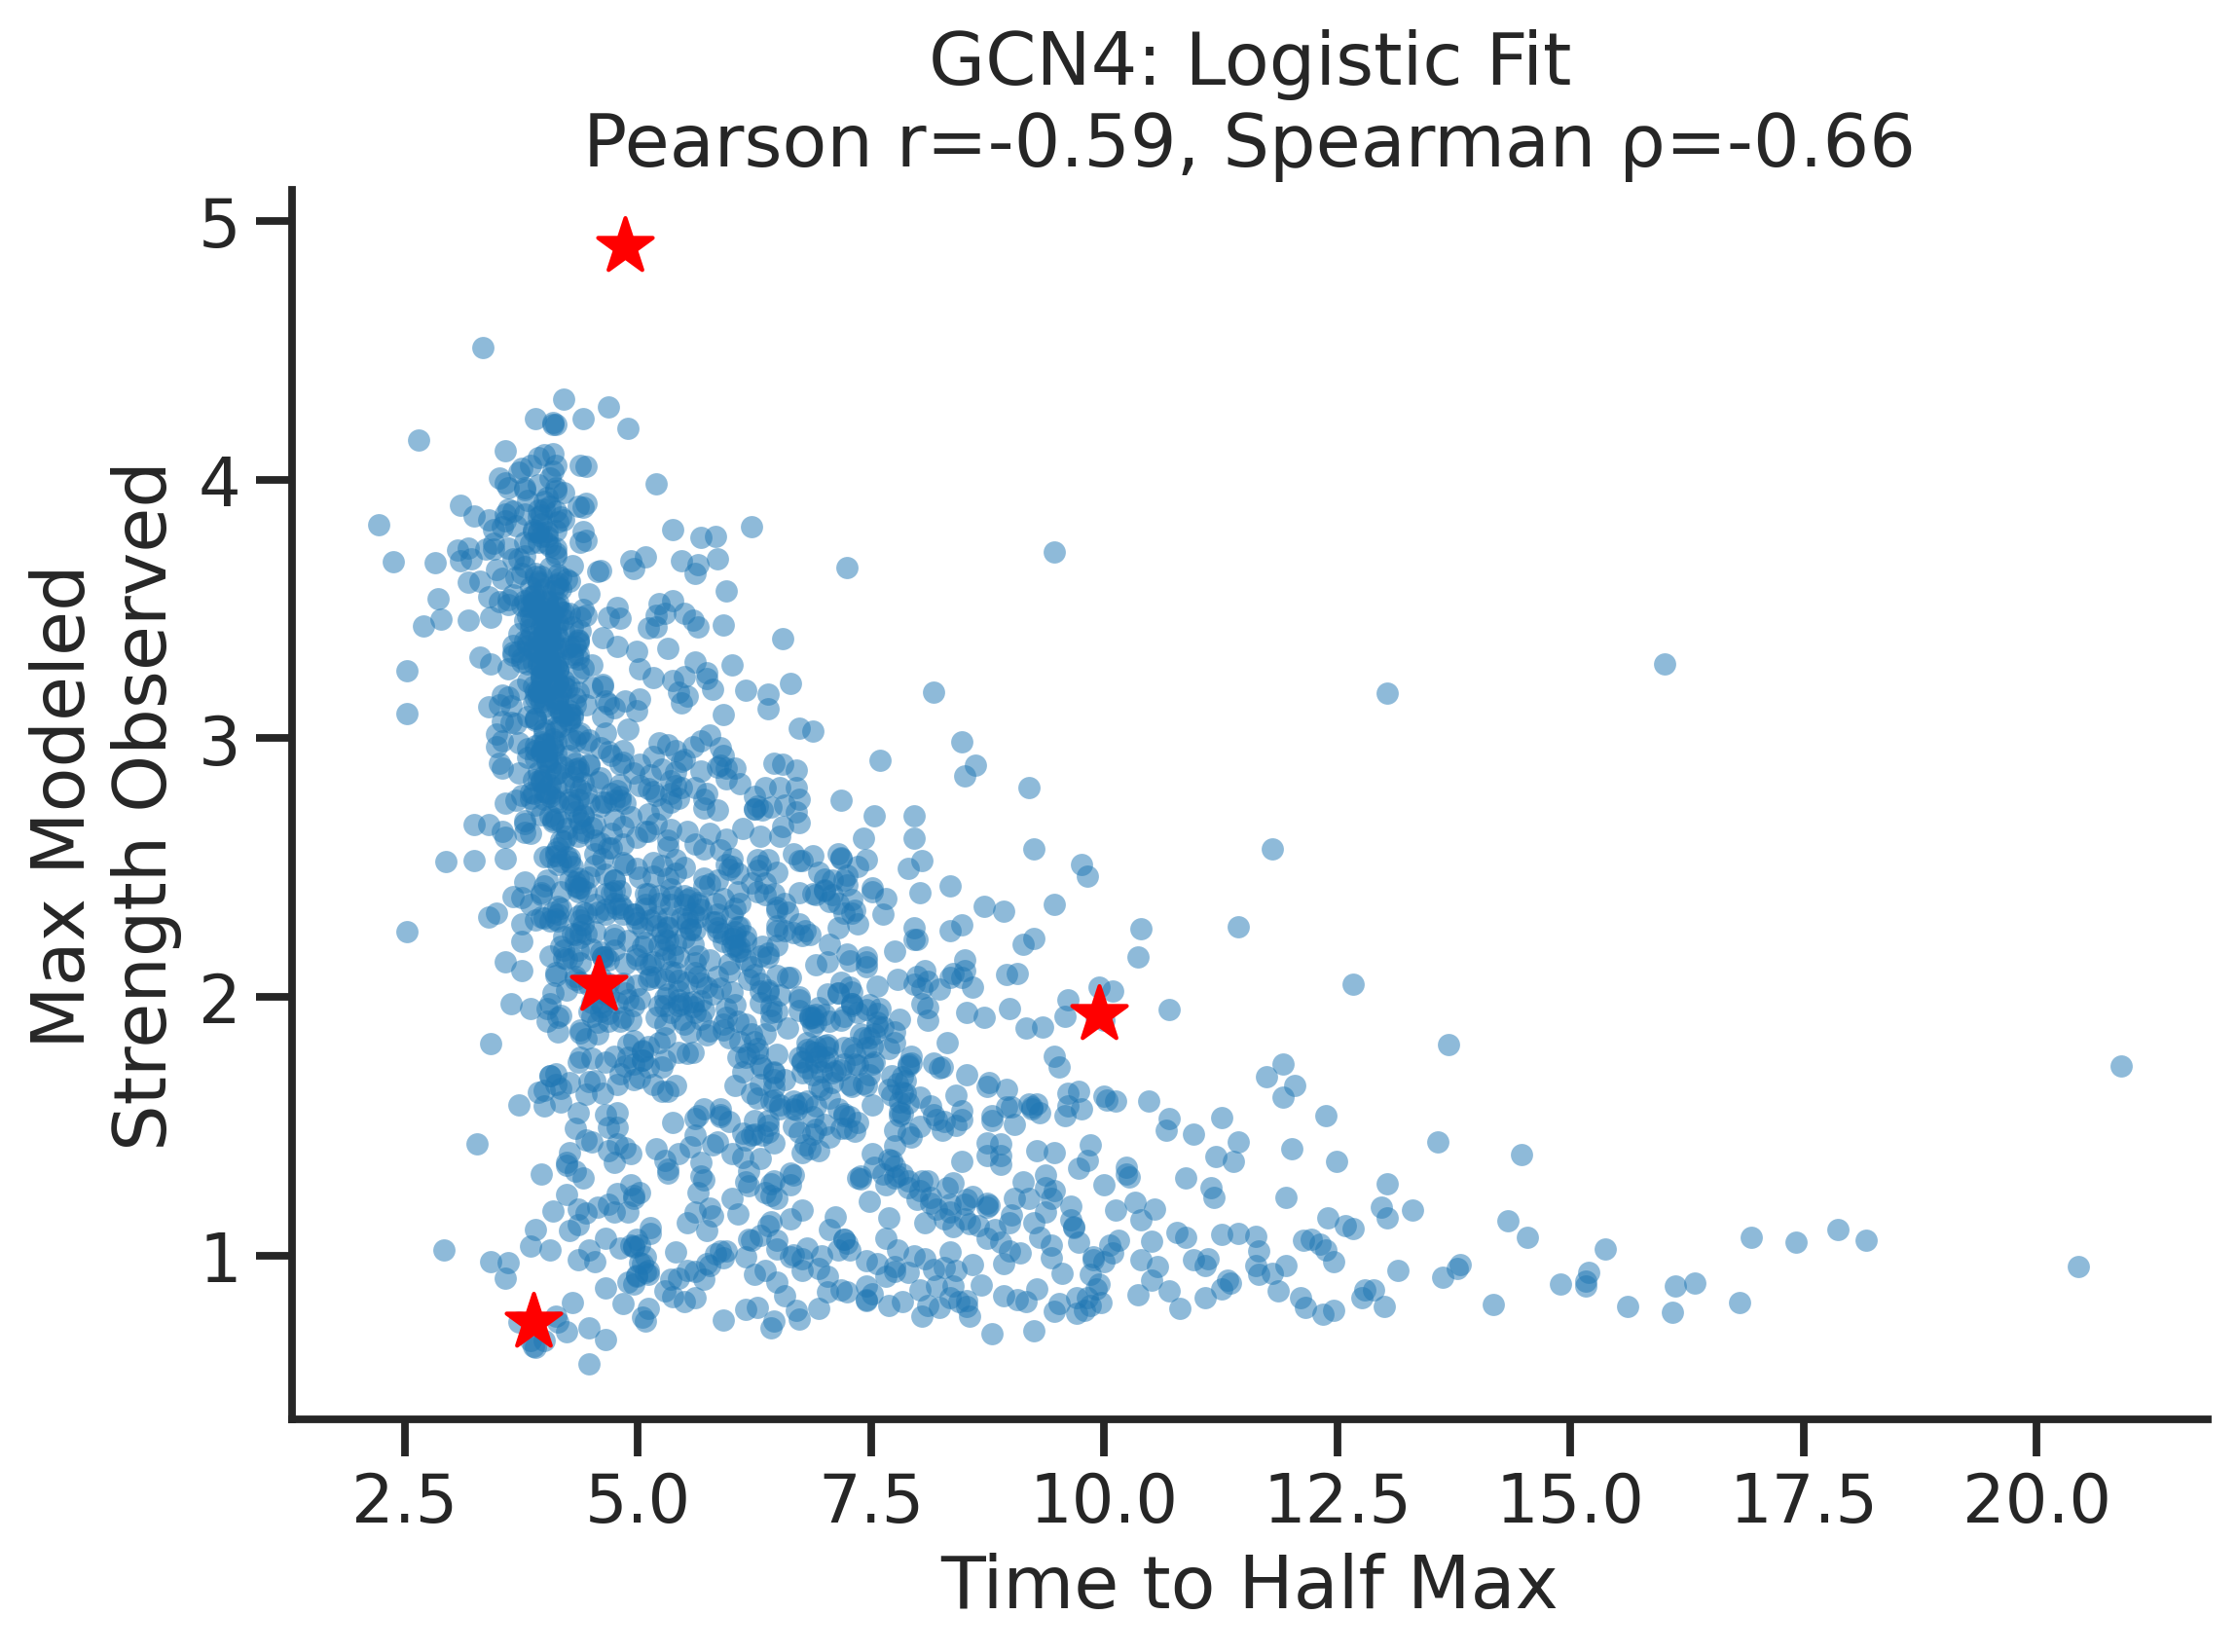

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half'], ok ['observed_strength'])
spearman_corr, spearman_p = spearmanr(ok['t_half'], ok ['observed_strength'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half'], ok['observed_strength'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['t_half'], to_plot['observed_strength'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)

ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Logistic Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

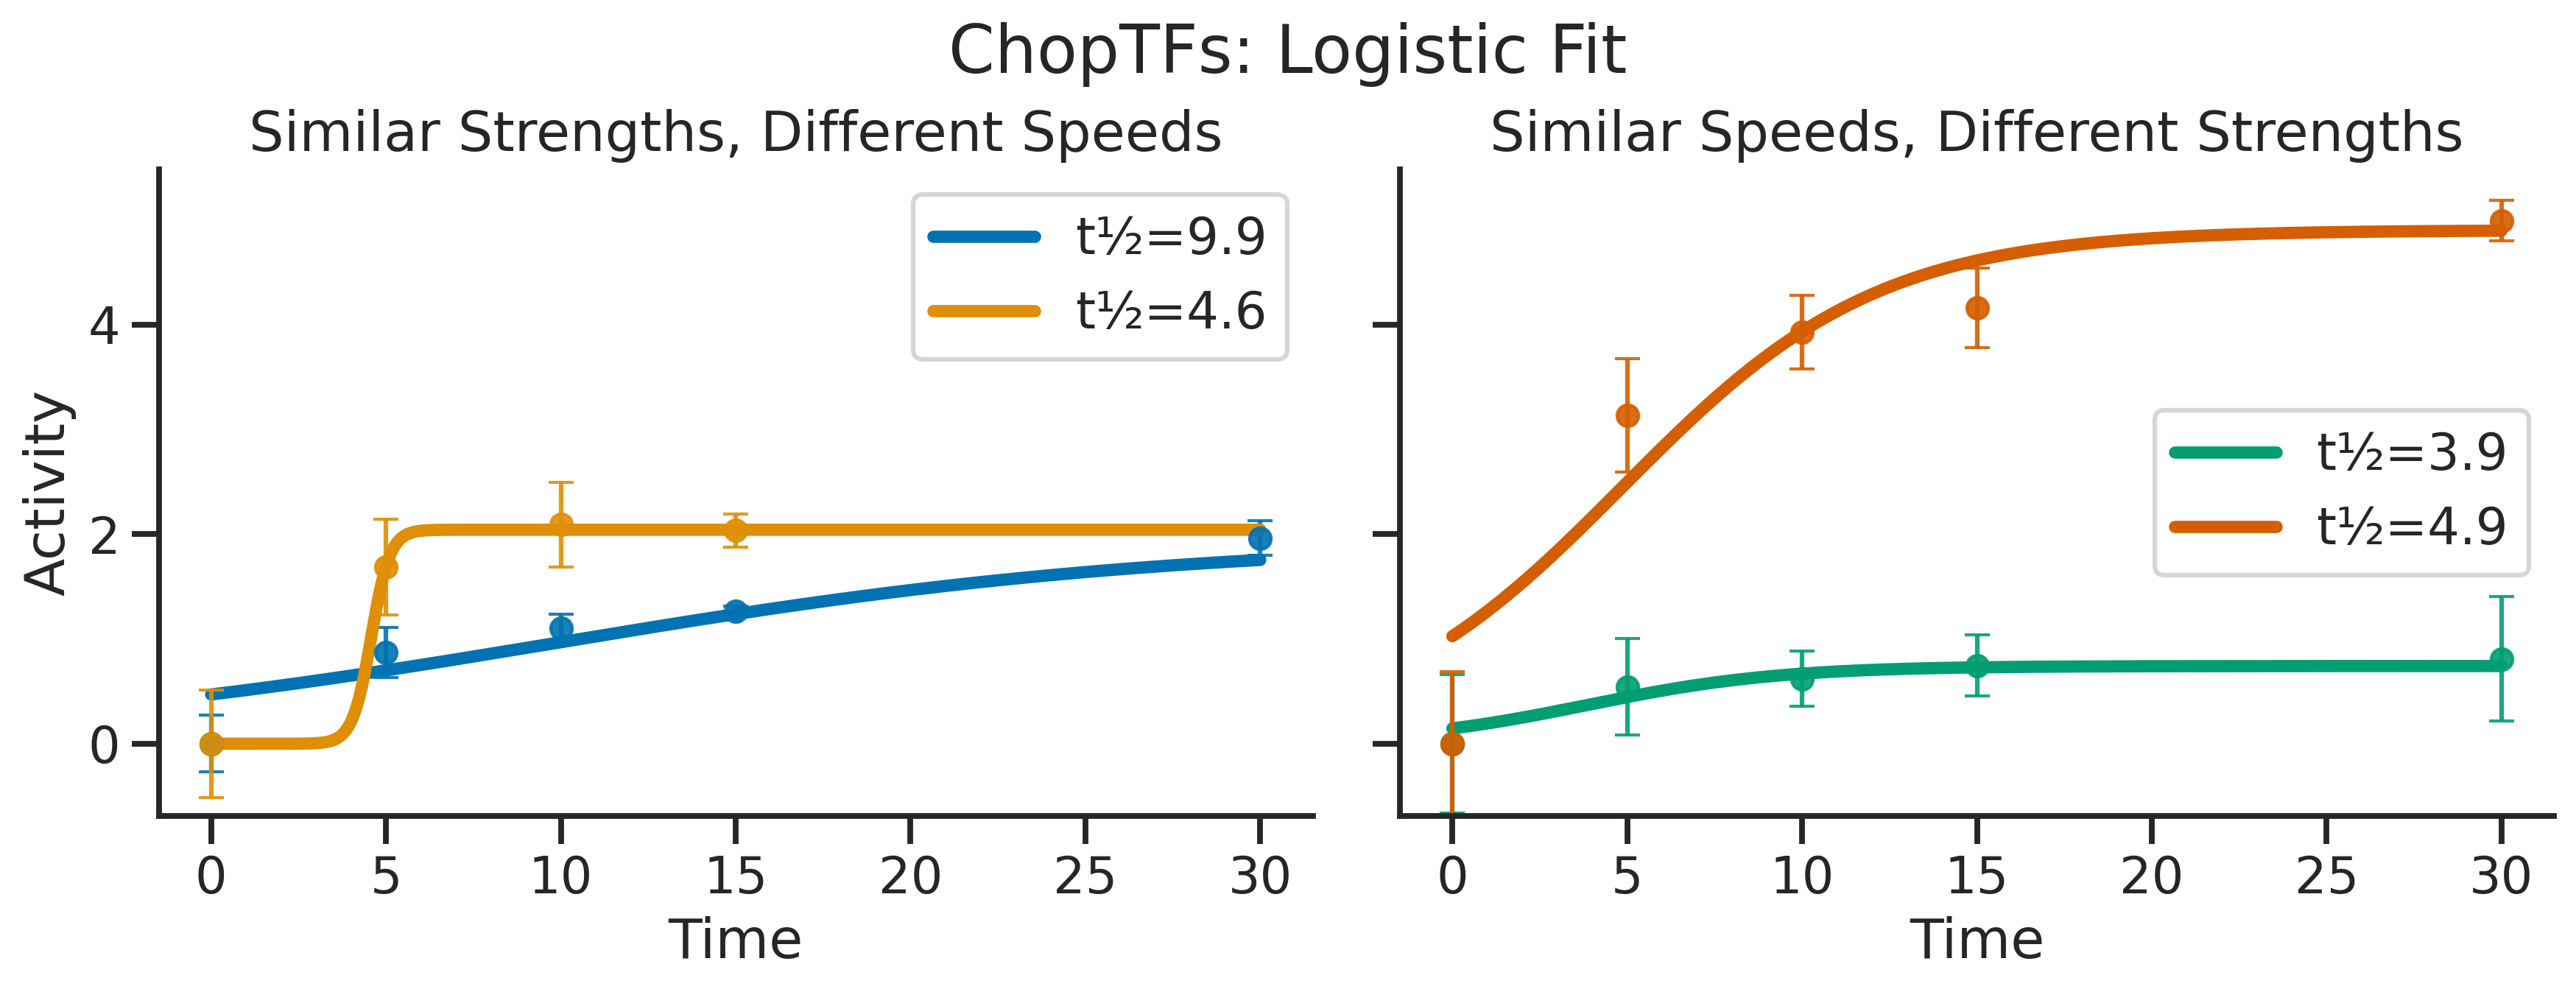

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')

# --- logistic function ---
def logistic(t, A, k, t_half):
    return A / (1 + np.exp(-k * (t - t_half)))

t_fine = np.linspace(0, activities['time'].max(), 300)
colors = sns.color_palette('colorblind', n_colors=4)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

# -----------------------------
# Similar Strength, Different Speeds
# -----------------------------
for idx in [0, 1]:

    row = to_plot.iloc[idx]
    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[0].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=4,
        markersize=7,
        alpha=0.9
    )

    axs[0].plot(
        t_fine,
        logistic(t_fine, row['observed_strength'], row['speed'], row['t_half']),
        color=colors[idx],
        linewidth=4,
        label=f"t½={row['t_half']:.1f}"
    )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].set_title("Similar Strengths, Different Speeds")
axs[0].legend()
sns.despine(ax=axs[0])

# -----------------------------
# Similar Speed, Different Strengths
# -----------------------------
for idx in [2, 3]:

    row = to_plot.iloc[idx]
    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[1].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=4,
        markersize=7,
        alpha=0.9
    )

    axs[1].plot(
        t_fine,
        logistic(t_fine, row['observed_strength'], row['speed'], row['t_half']),
        color=colors[idx],
        linewidth=4,
        label=f"t½={row['t_half']:.1f}"
    )

axs[1].set_xlabel('Time')
axs[1].set_title("Similar Speeds, Different Strengths")
axs[1].legend()
sns.despine(ax=axs[1])

# -----------------------------
# shared y-axis scaling
# -----------------------------
grps = activities[activities['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

plt.suptitle("ChopTFs: Logistic Fit", y=0.912)
plt.tight_layout()
plt.show()